In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

First 5 Rows of Dataset:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (100000, 9)

Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate Rows:
3854


In [4]:
# Remove duplicates
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Shape After Removing Duplicates: (96146, 9)


In [5]:
# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

print(df.head())

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Male  gender_Other  smoking_history_current  \
0         0        False         False                    False   
1         0        False         False                    False   
2         0         True         False                    False   
3         0        False         False                     True   
4         0         True         False                     True   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                 False             

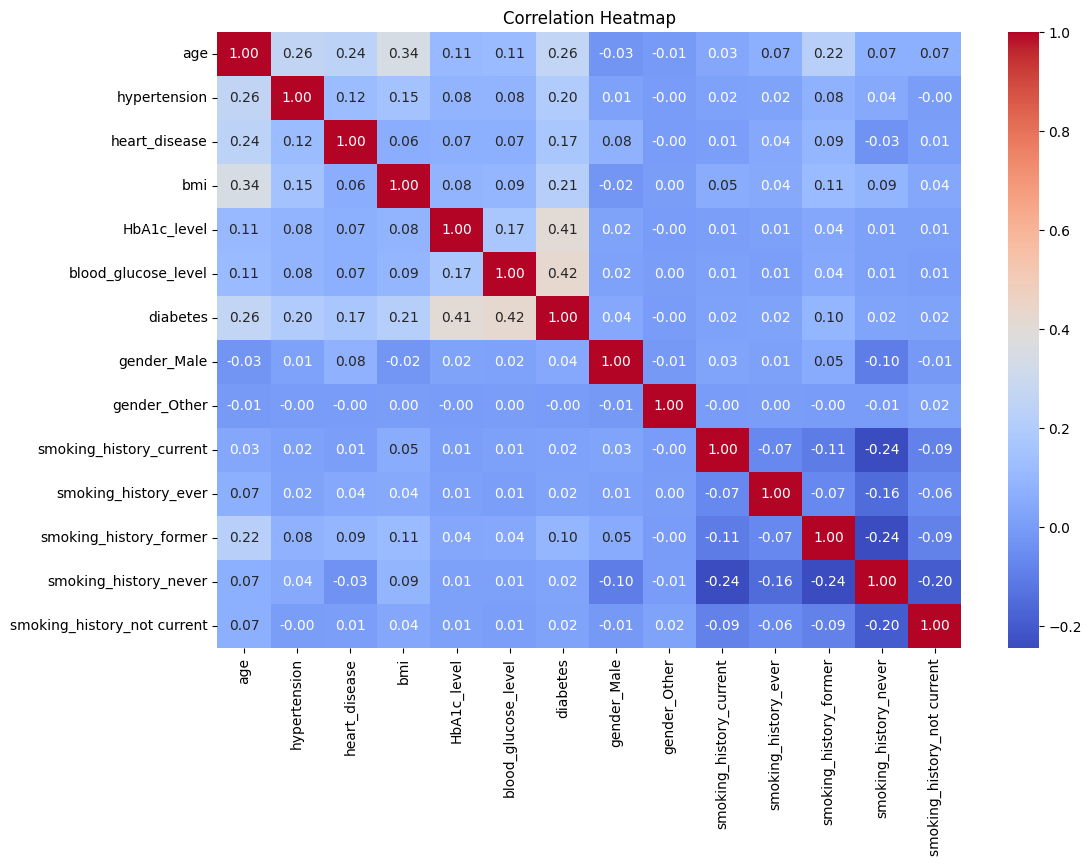

In [18]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [6]:
# Target column
target_column = "diabetes"

# Features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (96146, 13)
Target Shape: (96146,)


In [7]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (76916, 13)
Testing Data Shape: (19230, 13)


In [8]:
# Apply Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9596463858554343

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.87      0.64      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.81      0.86     19230
weighted avg       0.96      0.96      0.96     19230



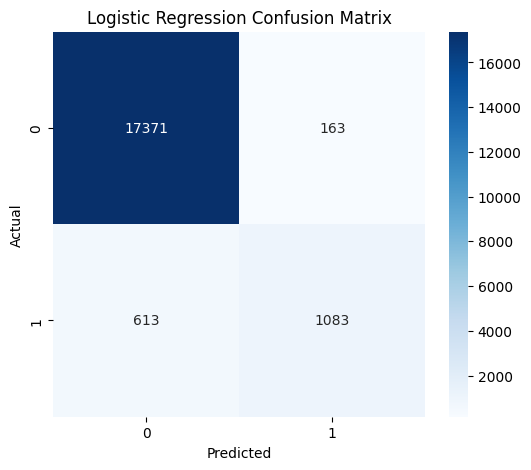

In [10]:
# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
# KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Predictions
knn_pred = knn_model.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9591783671346854

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17534
           1       0.89      0.62      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.80      0.85     19230
weighted avg       0.96      0.96      0.96     19230



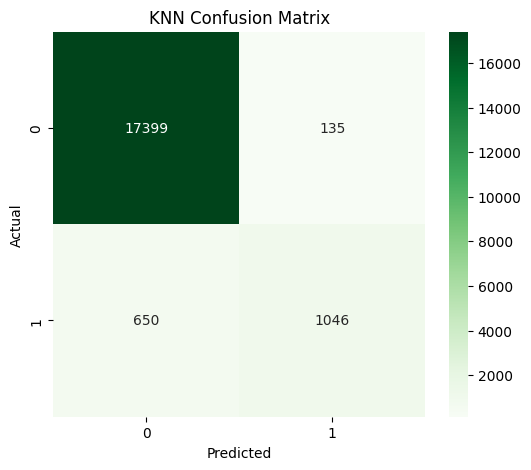

In [12]:
# Confusion Matrix
knn_cm = confusion_matrix(y_test, knn_pred)

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9692147685907436

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



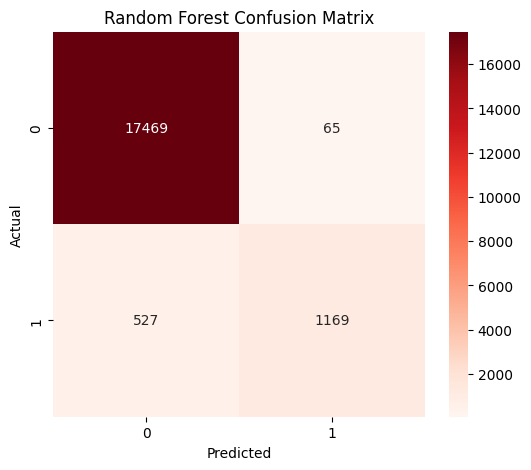

In [14]:
# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Reds')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
# Accuracy Comparison
accuracy_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

print(accuracy_results)

                 Model  Accuracy
0  Logistic Regression  0.959646
1                  KNN  0.959178
2        Random Forest  0.969215


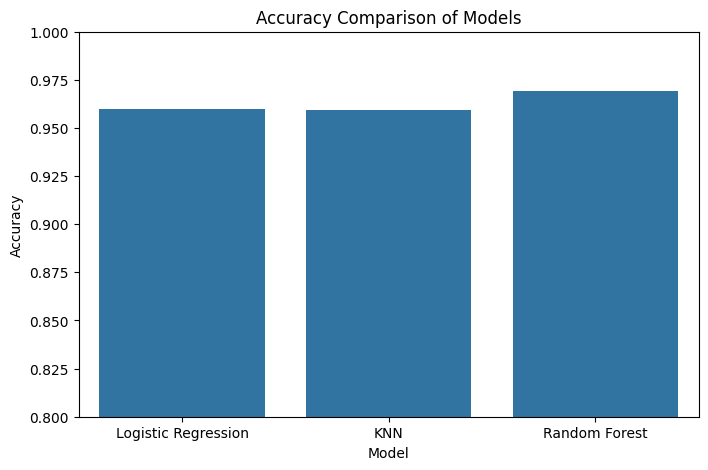

In [16]:
# Plot comparison graph
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=accuracy_results
)

plt.title("Accuracy Comparison of Models")
plt.ylim(0.8, 1.0)

plt.show()

In [17]:
best_model = accuracy_results.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       Random Forest
Accuracy         0.969215
Name: 2, dtype: object


In [19]:
# Training Accuracy

print("Logistic Regression Train Accuracy:",
      lr_model.score(X_train_scaled, y_train))

print("Logistic Regression Test Accuracy:",
      lr_model.score(X_test_scaled, y_test))


print("\nKNN Train Accuracy:",
      knn_model.score(X_train_scaled, y_train))

print("KNN Test Accuracy:",
      knn_model.score(X_test_scaled, y_test))


print("\nRandom Forest Train Accuracy:",
      rf_model.score(X_train_scaled, y_train))

print("Random Forest Test Accuracy:",
      rf_model.score(X_test_scaled, y_test))

Logistic Regression Train Accuracy: 0.9587082011545062
Logistic Regression Test Accuracy: 0.9596463858554343

KNN Train Accuracy: 0.9678610432159759
KNN Test Accuracy: 0.9591783671346854

Random Forest Train Accuracy: 0.999076915076187
Random Forest Test Accuracy: 0.9692147685907436


In [20]:
# New patient data
new_patient = pd.DataFrame({
    'age': [45],
    'hypertension': [1],
    'heart_disease': [0],
    'bmi': [28.5],
    'HbA1c_level': [6.8],
    'blood_glucose_level': [180],
    'gender_Male': [1],
    'gender_Other': [0],
    'smoking_history_current': [0],
    'smoking_history_ever': [0],
    'smoking_history_former': [1],
    'smoking_history_never': [0],
    'smoking_history_not current': [0]
})

In [21]:
# Scale input data
new_patient_scaled = scaler.transform(new_patient)

In [28]:
prediction = rf_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("The patient is likely Diabetic.")
else:
    print("The patient is likely Non-Diabetic.")

The patient is likely Diabetic.
